# Import Library

Mengimpor library yang digunakan untuk ekstraksi landmark tangan dan pembangunan model.

In [20]:
import mediapipe as mp

print(mp.__version__)
print(hasattr(mp, "solutions"))

0.10.14
True


In [21]:
import os
import cv2
import torch
import mediapipe as mp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

# Konfigurasi Device

Menentukan perangkat komputasi yang digunakan.

In [22]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : NVIDIA GeForce RTX 4050 Laptop GPU


# Konfigurasi MediaPipe

Menginisialisasi MediaPipe Hands untuk mendeteksi landmark tangan.

In [23]:
import mediapipe as mp

print(mp)
print(mp.__file__)
print(mp.__version__)

<module 'mediapipe' from 'c:\\Users\\VICTUS\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\mediapipe\\__init__.py'>
c:\Users\VICTUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\mediapipe\__init__.py
0.10.14


In [24]:
import mediapipe as mp

print(hasattr(mp, "solutions"))
print(dir(mp))

True
['CalculatorGraph', 'GraphInputStreamAddMode', 'Image', 'ImageFormat', 'ImageFrame', 'Matrix', 'Packet', 'Timestamp', 'ValidatedGraphConfig', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'calculators', 'model_ckpt_util', 'packet_creator', 'packet_getter', 'resource_util', 'solutions', 'tasks']


In [25]:
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

# Informasi Dataset

Memuat lokasi dataset dan daftar kelas gesture.

In [26]:
dataset_path = r"D:\SKC\Proyek Akhir CNN\dataset\asl_alphabet_train"

classes = sorted(os.listdir(dataset_path))

print("Jumlah Kelas :", len(classes))
print(classes)

Jumlah Kelas : 28
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


# Sampel Gambar

Menampilkan satu contoh gambar dari dataset.

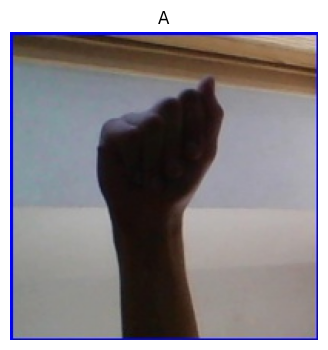

In [27]:
sample_class = classes[0]

sample_folder = os.path.join(
    dataset_path,
    sample_class
)

sample_image = os.listdir(sample_folder)[0]

sample_path = os.path.join(
    sample_folder,
    sample_image
)

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()

# Deteksi Landmark Tangan

Mendeteksi 21 titik landmark tangan menggunakan MediaPipe.

In [28]:
results = hands.process(img)

print(results.multi_hand_landmarks)

[landmark {
  x: 0.457428038
  y: 0.583321
  z: -6.47400725e-007
}
landmark {
  x: 0.570786357
  y: 0.5034284
  z: -0.0355798
}
landmark {
  x: 0.640131116
  y: 0.373975933
  z: -0.044406537
}
landmark {
  x: 0.651733875
  y: 0.264574856
  z: -0.0550684966
}
landmark {
  x: 0.634490609
  y: 0.179893553
  z: -0.0590976775
}
landmark {
  x: 0.545696914
  y: 0.270556211
  z: -0.00423305808
}
landmark {
  x: 0.586574078
  y: 0.209667951
  z: -0.0716262534
}
landmark {
  x: 0.592391729
  y: 0.307403505
  z: -0.111358792
}
landmark {
  x: 0.589894652
  y: 0.393817753
  z: -0.122083895
}
landmark {
  x: 0.467299581
  y: 0.282378
  z: -0.00464758743
}
landmark {
  x: 0.517436743
  y: 0.234142959
  z: -0.0775062814
}
landmark {
  x: 0.530205131
  y: 0.349560589
  z: -0.0962087959
}
landmark {
  x: 0.534969091
  y: 0.438434869
  z: -0.0864398479
}
landmark {
  x: 0.39551264
  y: 0.304352134
  z: -0.0160673261
}
landmark {
  x: 0.457142711
  y: 0.292900413
  z: -0.0848888382
}
landmark {
  x: 0.4

# Visualisasi Landmark

Menampilkan titik-titik landmark pada gambar tangan.

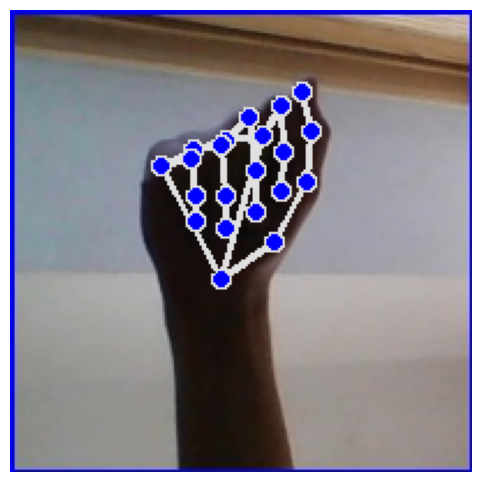

In [29]:
mp_draw = mp.solutions.drawing_utils

img_landmark = img.copy()

results = hands.process(img)

if results.multi_hand_landmarks:

    for hand_landmarks in results.multi_hand_landmarks:

        mp_draw.draw_landmarks(
            img_landmark,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )

plt.figure(figsize=(6,6))
plt.imshow(img_landmark)
plt.axis("off")
plt.show()

# Ekstraksi Landmark

Mengubah landmark tangan menjadi fitur numerik.

In [30]:
landmarks = []

for lm in results.multi_hand_landmarks[0].landmark:

    landmarks.extend([
        lm.x,
        lm.y,
        lm.z
    ])

print("Jumlah fitur :", len(landmarks))

print(landmarks[:10])

Jumlah fitur : 63
[0.4574280381202698, 0.5833209753036499, -6.474007250290015e-07, 0.5707863569259644, 0.5034283995628357, -0.035579800605773926, 0.6401311159133911, 0.373975932598114, -0.04440653696656227, 0.6517338752746582]


In [31]:
landmarks = []

for lm in results.multi_hand_landmarks[0].landmark:
    landmarks.extend([lm.x, lm.y, lm.z])

print("Jumlah fitur :", len(landmarks))

Jumlah fitur : 63


# Fungsi Ekstraksi Landmark

Mengubah gambar menjadi 63 fitur landmark tangan.

In [32]:
def extract_landmarks(image):

    results = hands.process(image)

    if results.multi_hand_landmarks:

        hand = results.multi_hand_landmarks[0]

        wrist_x = hand.landmark[0].x
        wrist_y = hand.landmark[0].y
        wrist_z = hand.landmark[0].z

        landmarks = []

        for lm in hand.landmark:

            landmarks.extend([
                lm.x - wrist_x,
                lm.y - wrist_y,
                lm.z - wrist_z
            ])

        return landmarks

    return None

In [33]:
features = extract_landmarks(img)

print("Jumlah fitur :", len(features))
print(features[:10])

Jumlah fitur : 63
[0.0, 0.0, 0.0, 0.11335831880569458, -0.07989257574081421, -0.0355791532050489, 0.18270307779312134, -0.2093450427055359, -0.04440588956583724, 0.19430583715438843]


# Ekstraksi Seluruh Dataset

Mengubah seluruh gambar gesture menjadi data landmark yang siap digunakan untuk pelatihan model.

In [34]:
data = []

for label in classes:

    folder = os.path.join(dataset_path, label)

    images = os.listdir(folder)

    print(f"Memproses kelas {label} ({len(images)} gambar)")

    for image_name in images:

        image_path = os.path.join(folder, image_name)

        img = cv2.imread(image_path)

        if img is None:
            continue

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        landmarks = extract_landmarks(img)

        if landmarks is not None:

            row = landmarks + [label]

            data.append(row)

print("Total Data :", len(data))

Memproses kelas A (3000 gambar)
Memproses kelas B (3000 gambar)
Memproses kelas C (3000 gambar)
Memproses kelas D (3000 gambar)
Memproses kelas E (3000 gambar)
Memproses kelas F (3000 gambar)
Memproses kelas G (3000 gambar)
Memproses kelas H (3000 gambar)
Memproses kelas I (3000 gambar)
Memproses kelas J (3000 gambar)
Memproses kelas K (3000 gambar)
Memproses kelas L (3000 gambar)
Memproses kelas M (3000 gambar)
Memproses kelas N (3000 gambar)
Memproses kelas O (3000 gambar)
Memproses kelas P (3000 gambar)
Memproses kelas Q (3000 gambar)
Memproses kelas R (3000 gambar)
Memproses kelas S (3000 gambar)
Memproses kelas T (3000 gambar)
Memproses kelas U (3000 gambar)
Memproses kelas V (3000 gambar)
Memproses kelas W (3000 gambar)
Memproses kelas X (3000 gambar)
Memproses kelas Y (3000 gambar)
Memproses kelas Z (3000 gambar)
Memproses kelas del (3000 gambar)
Memproses kelas space (3000 gambar)
Total Data : 63673


In [35]:
import pandas as pd

columns = [f"f{i}" for i in range(63)]
columns.append("label")

df = pd.DataFrame(
    data,
    columns=columns
)

print(df.shape)

(63673, 64)


In [36]:
df.to_csv("asl_landmarks.csv", index=False)

print("CSV berhasil disimpan")

CSV berhasil disimpan


In [37]:
df.to_csv("asl_landmarks.csv", index=False)

In [38]:
df["label"].value_counts().sort_index()

label
A        2187
B        2207
C        1988
D        2463
E        2308
F        2876
G        2440
H        2393
I        2384
J        2578
K        2700
L        2527
M        1565
N        1276
O        2265
P        2042
Q        2093
R        2541
S        2551
T        2349
U        2516
V        2548
W        2456
X        2158
Y        2585
Z        2351
del      1701
space    1625
Name: count, dtype: int64

In [39]:
print(df["label"].unique())
print("Jumlah kelas :", df["label"].nunique())

<StringArray>
[    'A',     'B',     'C',     'D',     'E',     'F',     'G',     'H',
     'I',     'J',     'K',     'L',     'M',     'N',     'O',     'P',
     'Q',     'R',     'S',     'T',     'U',     'V',     'W',     'X',
     'Y',     'Z',   'del', 'space']
Length: 28, dtype: str
Jumlah kelas : 28


In [40]:
df = df[df["label"] != "nothing"]

print(df["label"].nunique())
print(df["label"].unique())

28
<StringArray>
[    'A',     'B',     'C',     'D',     'E',     'F',     'G',     'H',
     'I',     'J',     'K',     'L',     'M',     'N',     'O',     'P',
     'Q',     'R',     'S',     'T',     'U',     'V',     'W',     'X',
     'Y',     'Z',   'del', 'space']
Length: 28, dtype: str


In [41]:
df.to_csv("asl_landmarks_clean.csv", index=False)

# Encoding Label

Mengubah label teks menjadi label numerik.

In [42]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label_encoded"] = encoder.fit_transform(
    df["label"]
)

print(encoder.classes_)
print("Jumlah kelas :", len(encoder.classes_))

['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']
Jumlah kelas : 28


# Pemisahan Fitur dan Label

In [43]:
X = df.iloc[:, :63].values
y = df["label_encoded"].values

print("X :", X.shape)
print("y :", y.shape)

X : (63673, 63)
y : (63673,)


# Train Test Split

Membagi dataset menjadi data latih dan data uji.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (50938, 63)
Test  : (12735, 63)


# Konversi ke Tensor PyTorch

In [45]:
import torch

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train.shape)
print(y_train.shape)

torch.Size([50938, 63])
torch.Size([50938])


# DataLoader

Membuat DataLoader untuk proses pelatihan model.

In [46]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_dataset = TensorDataset(
    X_train,
    y_train
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Train Batch :", len(train_loader))
print("Test Batch :", len(test_loader))

Train Batch : 398
Test Batch : 100


# Arsitektur Model

Model MLP digunakan untuk mengklasifikasikan 63 fitur landmark tangan ke dalam 28 kelas gesture.

In [47]:
import torch.nn as nn

class GestureNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(63, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 28)
        )

    def forward(self, x):
        return self.model(x)

# Konfigurasi Device

Menggunakan GPU CUDA jika tersedia.

In [48]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


# Inisialisasi Model

In [49]:
model = GestureNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

GestureNet(
  (model): Sequential(
    (0): Linear(in_features=63, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=28, bias=True)
  )
)


# Pelatihan Model

In [50]:
num_epochs = 20

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/20] Loss: 1.2784
Epoch [2/20] Loss: 0.4081
Epoch [3/20] Loss: 0.2489
Epoch [4/20] Loss: 0.1881
Epoch [5/20] Loss: 0.1567
Epoch [6/20] Loss: 0.1339
Epoch [7/20] Loss: 0.1204
Epoch [8/20] Loss: 0.1091
Epoch [9/20] Loss: 0.1016
Epoch [10/20] Loss: 0.0936
Epoch [11/20] Loss: 0.0896
Epoch [12/20] Loss: 0.0853
Epoch [13/20] Loss: 0.0785
Epoch [14/20] Loss: 0.0759
Epoch [15/20] Loss: 0.0732
Epoch [16/20] Loss: 0.0697
Epoch [17/20] Loss: 0.0697
Epoch [18/20] Loss: 0.0654
Epoch [19/20] Loss: 0.0620
Epoch [20/20] Loss: 0.0611


# Evaluasi Model

In [51]:
from sklearn.metrics import accuracy_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            y_batch.numpy()
        )

acc = accuracy_score(
    all_labels,
    all_preds
)

print(
    f"Accuracy: {acc*100:.2f}%"
)

Accuracy: 98.60%


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

           A       0.98      0.99      0.99       437
           B       1.00      1.00      1.00       441
           C       0.98      1.00      0.99       398
           D       0.99      0.99      0.99       493
           E       0.99      1.00      0.99       462
           F       1.00      0.99      0.99       575
           G       0.99      1.00      0.99       488
           H       0.99      1.00      0.99       479
           I       0.99      0.99      0.99       477
           J       1.00      0.99      1.00       516
           K       1.00      0.99      0.99       540
           L       1.00      1.00      1.00       505
           M       0.89      0.96      0.92       313
           N       0.93      0.85      0.89       255
           O       0.99      1.00      0.99       453
           P       0.99      0.98      0.98       408
           Q       0.99      0.99      0.99       419
           R       0.98    

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm.shape)

(28, 28)


In [54]:
torch.save(
    model.state_dict(),
    "gesture_model.pth"
)

print("Model berhasil disimpan")

Model berhasil disimpan


In [55]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("Encoder berhasil disimpan")

Encoder berhasil disimpan


In [56]:
import os

print(os.getcwd())

d:\SKC\SKC CNN


In [57]:
import os

print(os.path.exists("gesture_model.pth"))
print(os.path.exists("label_encoder.pkl"))

True
True


In [58]:
import os

print(os.path.exists("asl_landmarks.csv"))

True


In [59]:
print(type(model))

<class '__main__.GestureNet'>


In [60]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

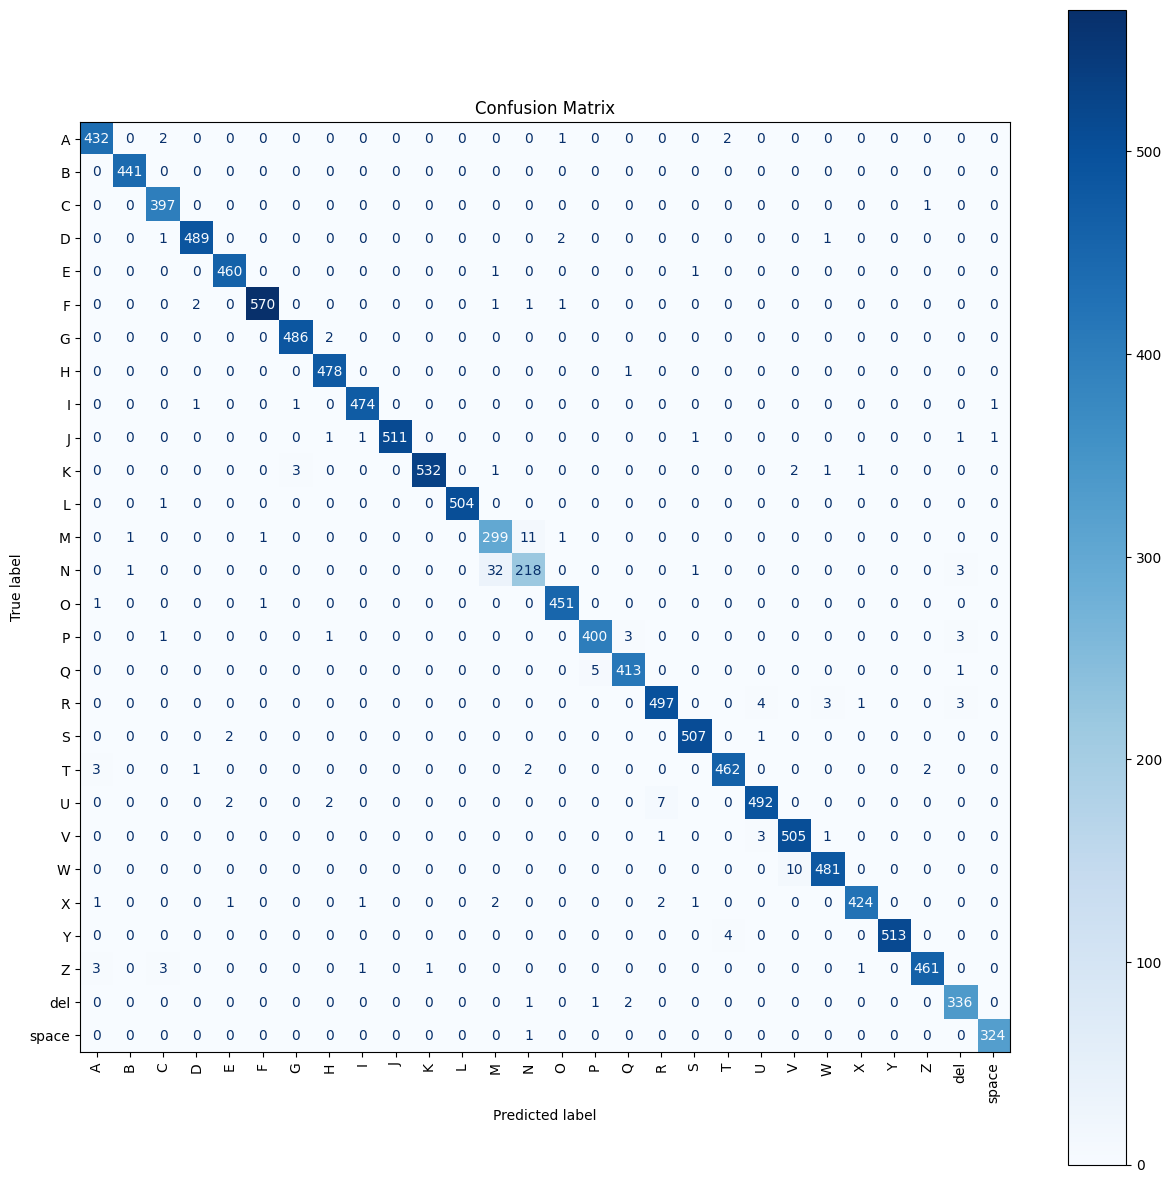

In [61]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(15,15))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()